✅ Registros entrenamiento: 5927
✅ Registros prueba: 2316

📊 Resultados para Entrenamiento (2010–2018)
Accuracy: 0.916
Precision: 0.9
Recall: 0.841
F1: 0.869
ROC-AUC: 0.957

Matriz de Confusión:
 [[3765  185]
 [ 315 1662]]

               precision    recall  f1-score   support

       False       0.92      0.95      0.94      3950
        True       0.90      0.84      0.87      1977

    accuracy                           0.92      5927
   macro avg       0.91      0.90      0.90      5927
weighted avg       0.92      0.92      0.91      5927



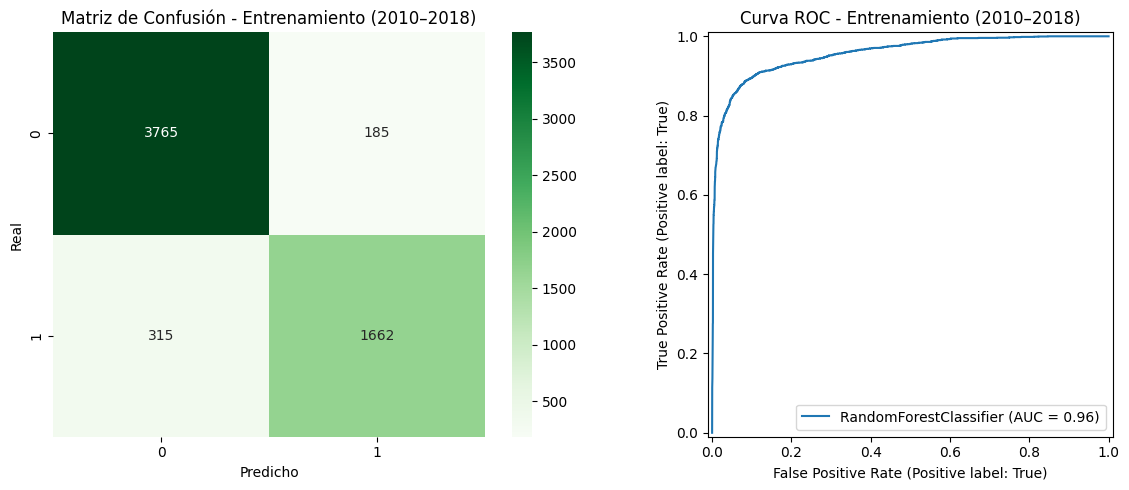


📊 Resultados para Prueba (2019–2022)
Accuracy: 0.875
Precision: 0.798
Recall: 0.818
F1: 0.808
ROC-AUC: 0.914

Matriz de Confusión:
 [[1419  154]
 [ 135  608]]

               precision    recall  f1-score   support

       False       0.91      0.90      0.91      1573
        True       0.80      0.82      0.81       743

    accuracy                           0.88      2316
   macro avg       0.86      0.86      0.86      2316
weighted avg       0.88      0.88      0.88      2316



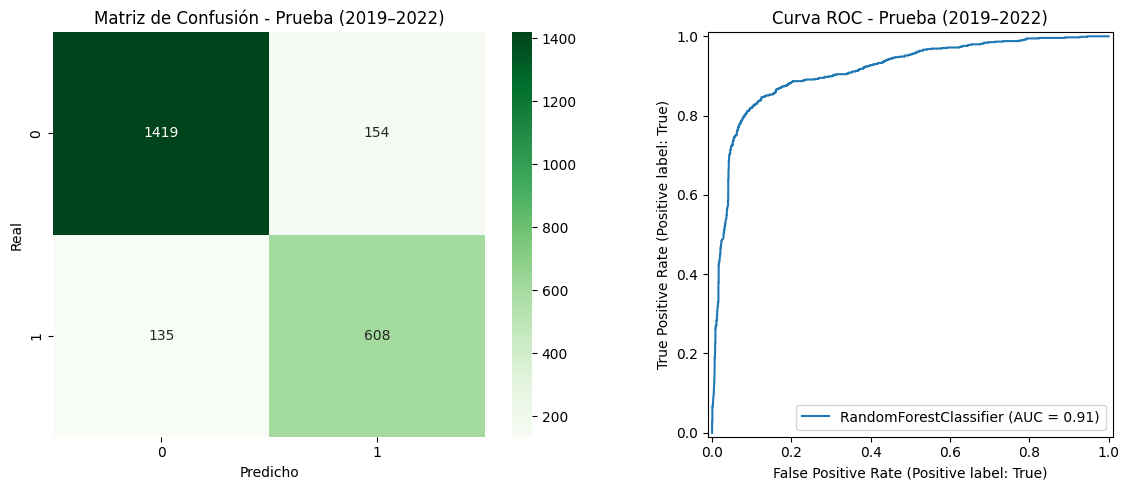

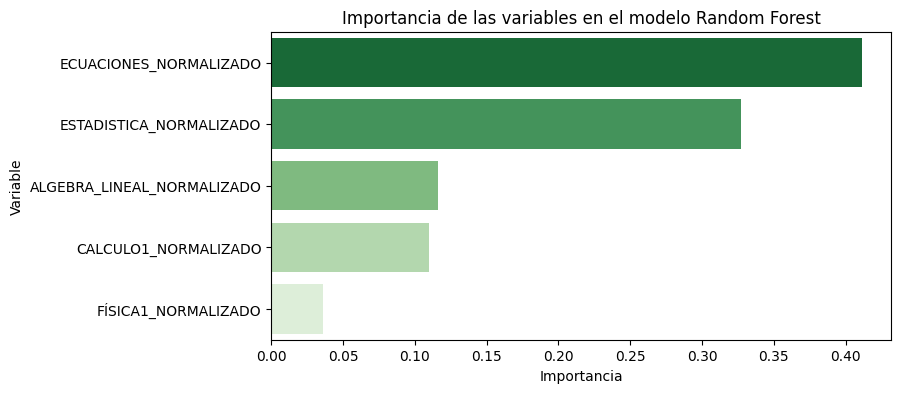

In [2]:
# ============================================
# 🔹 1. Librerías necesarias
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# ============================================
# 🔹 2. Cargar datos
# ============================================
df = pd.read_excel("base_para_ml.xlsx")

# Variables de entrada (features)
features = [
    'CALCULO1_NORMALIZADO', 'ECUACIONES_NORMALIZADO',
    'ESTADISTICA_NORMALIZADO', 'FÍSICA1_NORMALIZADO',
    'ALGEBRA_LINEAL_NORMALIZADO'
]
target = 'DESERTOR'

# ============================================
# 🔹 3. Separar cohortes entrenamiento (≤2018) y prueba (2019–2022)
# ============================================
df['COHORTE'] = df['COHORTE'].astype(str)
df['AÑO_COHORTE'] = df['COHORTE'].str[:4].astype(int)

train_df = df[df['AÑO_COHORTE'] <= 2018]
test_df = df[(df['AÑO_COHORTE'] >= 2019) & (df['AÑO_COHORTE'] <= 2022)]

# Eliminar filas con valores faltantes
train_df = train_df.dropna(subset=features + [target])
test_df = test_df.dropna(subset=features)

# Variables predictoras y objetivo
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target] if target in test_df.columns else None

print(f"✅ Registros entrenamiento: {X_train.shape[0]}")
print(f"✅ Registros prueba: {X_test.shape[0]}")

# ============================================
# 🔹 4. Entrenamiento del modelo Random Forest
# ============================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight='balanced',   # útil si hay desbalance en DESERTOR
    criterion='gini'
)
rf_model.fit(X_train, y_train)

# ============================================
# 🔹 5. Función de evaluación general
# ============================================
def evaluar_rf(modelo, X, y, nombre):
    y_pred = modelo.predict(X)
    y_proba = modelo.predict_proba(X)[:, 1]

    print(f"\n📊 Resultados para {nombre}")
    print("Accuracy:", round(accuracy_score(y, y_pred), 3))
    print("Precision:", round(precision_score(y, y_pred), 3))
    print("Recall:", round(recall_score(y, y_pred), 3))
    print("F1:", round(f1_score(y, y_pred), 3))
    print("ROC-AUC:", round(roc_auc_score(y, y_proba), 3))
    print("\nMatriz de Confusión:\n", confusion_matrix(y, y_pred))
    print("\n", classification_report(y, y_pred))

    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Matriz de confusión mejorada
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - {nombre}')
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real")
    axes[0].set_ylim(len(cm), 0)  # evita que la gráfica salga en blanco

    # Curva ROC
    RocCurveDisplay.from_estimator(modelo, X, y, ax=axes[1])
    axes[1].set_title(f'Curva ROC - {nombre}')

    plt.tight_layout()
    plt.show()

# ============================================
# 🔹 6. Evaluación del modelo
# ============================================
evaluar_rf(rf_model, X_train, y_train, "Entrenamiento (2010–2018)")

if y_test is not None and len(y_test) > 0:
    evaluar_rf(rf_model, X_test, y_test, "Prueba (2019–2022)")
else:
    print("\n⚠️ Cohortes 2019+ no tienen 'DESERTOR'; generando solo predicciones.")
    test_df['PROB_DESERCIÓN'] = rf_model.predict_proba(X_test)[:, 1]

# ============================================
# 🔹 7. Importancia de las variables
# ============================================
feat_imp = pd.DataFrame({
    'Variable': features,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=feat_imp,
    x='Importancia',
    y='Variable',
    hue='Variable',
    palette='Greens_r',
    dodge=False,
    legend=False
)
plt.title("Importancia de las variables en el modelo Random Forest")
plt.show()

# ============================================
# 🔹 8. Distribución de probabilidades de deserción
# ============================================
if 'PROB_DESERCIÓN' in test_df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(test_df['PROB_DESERCIÓN'], kde=True, bins=20, color='green')
    plt.title("Distribución de probabilidad de deserción (Cohortes 2019–2022)")
    plt.xlabel("Probabilidad de Deserción")
    plt.show()


🔍 Iniciando análisis agregado de predicciones...

Total estudiantes (2019+): 2316
Predichos desertores: 762 (32.9%)
Predichos no desertores: 1554 (67.1%)


/tmp/ipython-input-1164384555.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=test_df, x='PRED_DESERTOR', palette='pastel')


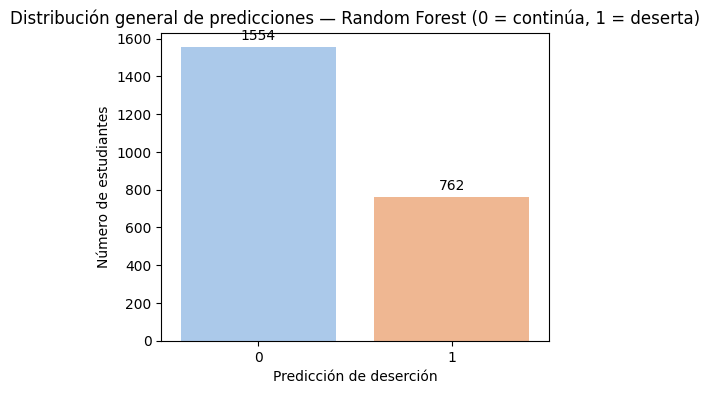


📈 Porcentaje proyectado de desertores por cohorte:
  COHORTE  Porcentaje_desertores
0  2019-1              31.858407
1  2019-2              31.284916
2  2020-1              27.455919
3  2020-2              34.117647
4  2021-1              33.418367


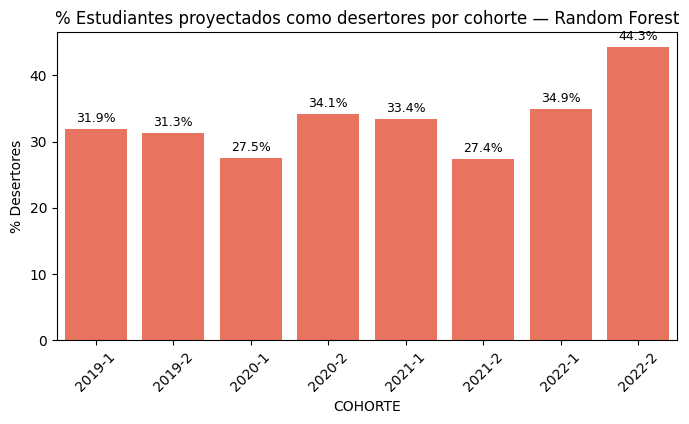

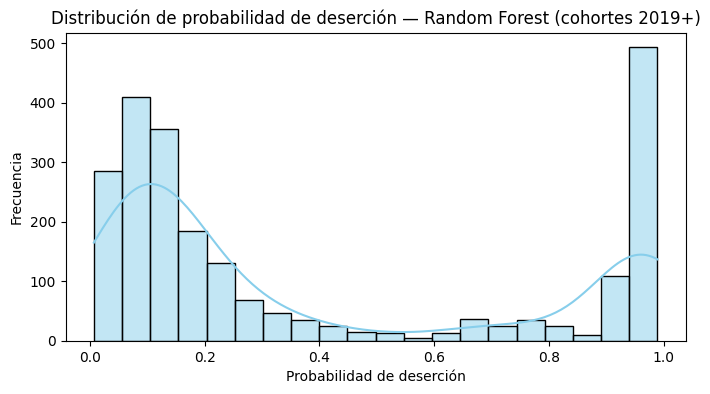

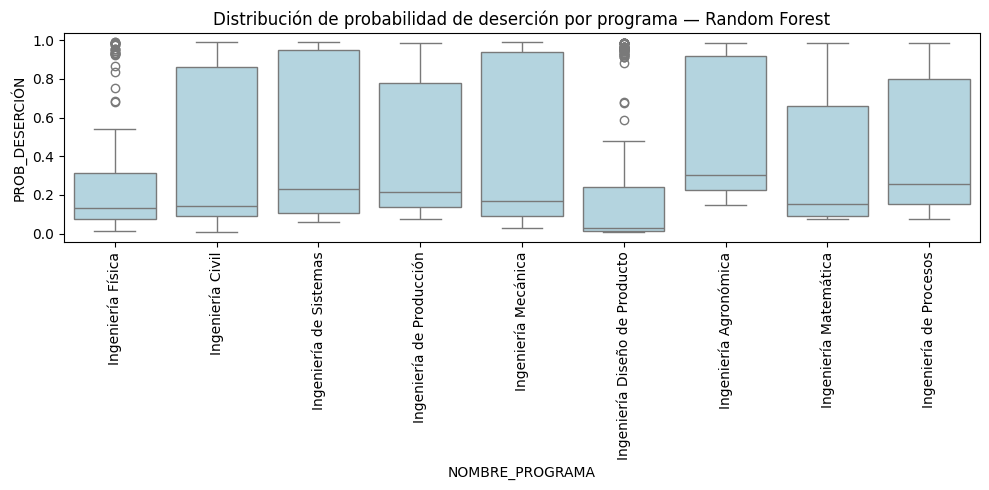


🏫 Top 10 programas con mayor probabilidad media de deserción:
NOMBRE_PROGRAMA
Ingeniería Agronómica            0.481515
Ingeniería de Sistemas           0.468581
Ingeniería de Procesos           0.447025
Ingeniería de Producción         0.434730
Ingeniería Mecánica              0.417609
Ingeniería Civil                 0.380682
Ingeniería Matemática            0.339798
Ingeniería Física                0.280643
Ingeniería Diseño de Producto    0.245779
Name: PROB_DESERCIÓN, dtype: float64


/tmp/ipython-input-1164384555.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_programas.values, y=top_programas.index, palette='Greens_r')


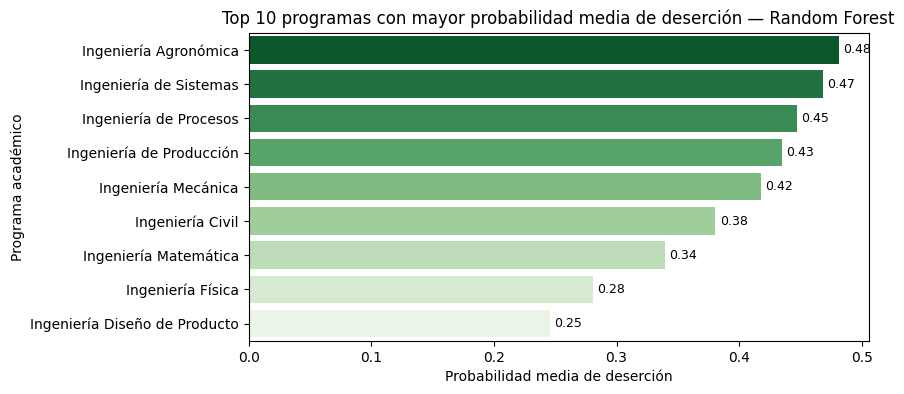

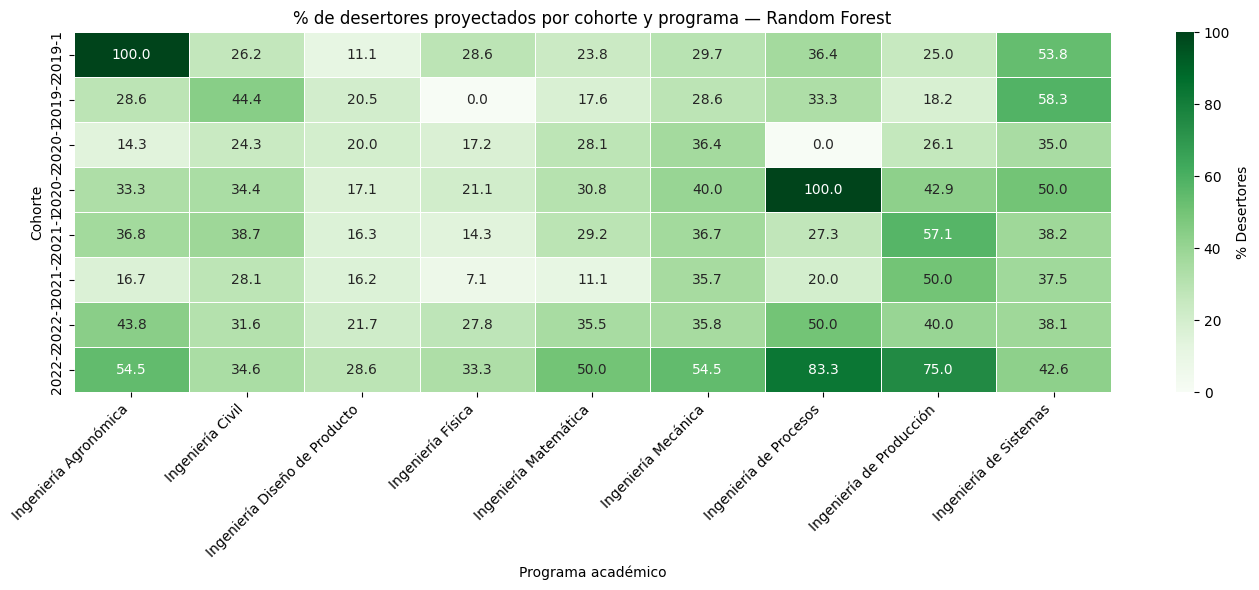


✅ Análisis completo de predicciones finalizado (Random Forest).


In [3]:
# ============================================
# 🔹 11. Análisis agregado de predicciones por estudiante / cohorte / programa (Random Forest)
# ============================================

print("🔍 Iniciando análisis agregado de predicciones...\n")

# Asegurar que las predicciones existan
if 'PROB_DESERCIÓN' not in test_df.columns:
    test_df['PROB_DESERCIÓN'] = rf_model.predict_proba(X_test)[:, 1]  # ✅ se cambia a rf_model

# Clasificación binaria según umbral (0.5)
test_df['PRED_DESERTOR'] = np.where(test_df['PROB_DESERCIÓN'] >= 0.5, 1, 0)

# =====================================================
# 1️⃣ Distribución general de predicciones
# =====================================================
total = len(test_df)
desertores = test_df['PRED_DESERTOR'].sum()
no_desertores = total - desertores
porc_desertores = round(desertores / total * 100, 2)

print(f"Total estudiantes (2019+): {total}")
print(f"Predichos desertores: {desertores} ({porc_desertores}%)")
print(f"Predichos no desertores: {no_desertores} ({round(100 - porc_desertores, 2)}%)")

# Gráfico de distribución general
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=test_df, x='PRED_DESERTOR', palette='pastel')
plt.title('Distribución general de predicciones — Random Forest (0 = continúa, 1 = deserta)')
plt.xlabel('Predicción de deserción')
plt.ylabel('Número de estudiantes')

# Agregar etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3),
                textcoords='offset points')
plt.show()

# =====================================================
# 2️⃣ Desertores proyectados por cohorte
# =====================================================
if 'COHORTE' in test_df.columns:
    cohorte_summary = (
        test_df.groupby('COHORTE')['PRED_DESERTOR']
        .mean()
        .reset_index(name='Porcentaje_desertores')
    )
    cohorte_summary['Porcentaje_desertores'] *= 100

    print("\n📈 Porcentaje proyectado de desertores por cohorte:")
    print(cohorte_summary.head())

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=cohorte_summary, x='COHORTE', y='Porcentaje_desertores', color='tomato')
    plt.title('% Estudiantes proyectados como desertores por cohorte — Random Forest')
    plt.xticks(rotation=45)
    plt.ylabel('% Desertores')

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                    textcoords='offset points')
    plt.show()

# =====================================================
# 3️⃣ Distribución de la probabilidad de deserción
# =====================================================
plt.figure(figsize=(8, 4))
sns.histplot(test_df['PROB_DESERCIÓN'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de probabilidad de deserción — Random Forest (cohortes 2019+)')
plt.xlabel('Probabilidad de deserción')
plt.ylabel('Frecuencia')
plt.show()

# =====================================================
# 4️⃣ Distribución de la probabilidad por programa
# =====================================================
if 'NOMBRE_PROGRAMA' in test_df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=test_df, x='NOMBRE_PROGRAMA', y='PROB_DESERCIÓN', color='lightblue')
    plt.title('Distribución de probabilidad de deserción por programa — Random Forest')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 5️⃣ Top 10 programas con mayor probabilidad media de deserción
    # =====================================================
    top_programas = (
        test_df.groupby('NOMBRE_PROGRAMA')['PROB_DESERCIÓN']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    print("\n🏫 Top 10 programas con mayor probabilidad media de deserción:")
    print(top_programas)

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=top_programas.values, y=top_programas.index, palette='Greens_r')
    plt.title('Top 10 programas con mayor probabilidad media de deserción — Random Forest')
    plt.xlabel('Probabilidad media de deserción')
    plt.ylabel('Programa académico')

    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.2f}',
                    (width, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=9, color='black', xytext=(3, 0),
                    textcoords='offset points')
    plt.show()

# =====================================================
# 6️⃣ Distribución conjunta cohorte–programa (mapa de calor)
# =====================================================
if {'COHORTE', 'NOMBRE_PROGRAMA'}.issubset(test_df.columns):
    programas_completos = sorted(test_df['NOMBRE_PROGRAMA'].unique())

    pivot = (
        test_df.groupby(['COHORTE', 'NOMBRE_PROGRAMA'])['PRED_DESERTOR']
        .mean()
        .unstack(fill_value=0) * 100
    )

    for prog in programas_completos:
        if prog not in pivot.columns:
            pivot[prog] = 0

    pivot = pivot[programas_completos]

    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, cmap='Greens', annot=True, fmt=".1f", linewidths=0.5,
                cbar_kws={'label': '% Desertores'})
    plt.title('% de desertores proyectados por cohorte y programa — Random Forest')
    plt.xlabel('Programa académico')
    plt.ylabel('Cohorte')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("\n✅ Análisis completo de predicciones finalizado (Random Forest).")
